In [16]:
import pandas as pd
df = pd.read_csv('/content/customer_churn_data.csv')
df.head(5)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


EDA + DATA CLEANING

In [17]:
df.count() #to see if there's any missing values

,0
CustomerID,1000
Age,1000
Gender,1000
Tenure,1000
MonthlyCharges,1000
ContractType,1000
InternetService,703
TotalCharges,1000
TechSupport,1000
Churn,1000


In [18]:
df['InternetService']

,InternetService
0,Fiber Optic
1,Fiber Optic
2,Fiber Optic
3,DSL
4,NaN
...,...
995,Fiber Optic
996,NaN
997,Fiber Optic
998,NaN


In [19]:
df['InternetService'] = df['InternetService'].fillna(df['InternetService'].mode()[0]) #filling the null values with the most frequent ones
df['InternetService']

,InternetService
0,Fiber Optic
1,Fiber Optic
2,Fiber Optic
3,DSL
4,Fiber Optic
...,...
995,Fiber Optic
996,Fiber Optic
997,Fiber Optic
998,Fiber Optic


In [20]:
print(df['InternetService'].nunique()) #to see how many type of services are there to determine  what kind of encoding is needed
print(df['ContractType'].nunique())

2
3


In [21]:
df.select_dtypes(include='object').columns #determining the categorical features

Index(['Gender', 'ContractType', 'InternetService', 'TechSupport', 'Churn'], dtype='object')

ENCODING


In [22]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0}) #encoding on binary features
df['InternetService'] = df['InternetService'].map({'Fiber Optic': 1, 'DSL': 0})
df[['Churn', 'TechSupport']] = df[['Churn', 'TechSupport']].replace({'Yes': 1, 'No': 0})
df.head(5)

/tmp/ipykernel_2535/1862631615.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['Churn', 'TechSupport']] = df[['Churn', 'TechSupport']].replace({'Yes': 1, 'No': 0})


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,1,4,88.35,Month-to-Month,1,353.40,1,1
1,2,43,1,0,36.67,Month-to-Month,1,0.00,1,1
2,3,51,0,2,63.79,Month-to-Month,1,127.58,0,1
3,4,60,0,8,102.34,One-Year,0,818.72,1,1
4,5,42,1,32,69.01,Month-to-Month,1,2208.32,0,1


HOT-ONE ENCODING


In [23]:
df = pd.get_dummies(df, columns=['ContractType']) #encoding for more than 2 values per feature
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head(5)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,InternetService,TotalCharges,TechSupport,Churn,ContractType_Month-to-Month,ContractType_One-Year,ContractType_Two-Year
0,1,49,1,4,88.35,1,353.40,1,1,1,0,0
1,2,43,1,0,36.67,1,0.00,1,1,1,0,0
2,3,51,0,2,63.79,1,127.58,0,1,1,0,0
3,4,60,0,8,102.34,0,818.72,1,1,0,1,0
4,5,42,1,32,69.01,1,2208.32,0,1,1,0,0


In [24]:
(df.max() - df.min()) #to determine the value range(to understand the scaling Necessity)

,0
CustomerID,999.00
Age,71.00
Gender,1.00
Tenure,122.00
MonthlyCharges,89.96
InternetService,1.00
TotalCharges,12416.25
TechSupport,1.00
Churn,1.00
ContractType_Month-to-Month,1.00


SCALING

In [26]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
(df.max() - df.min())

,0
CustomerID,999.000000
Age,7.250195
Gender,1.000000
Tenure,6.460796
MonthlyCharges,3.500495
InternetService,1.000000
TotalCharges,7.903562
TechSupport,1.000000
Churn,1.000000
ContractType_Month-to-Month,1.000000


In [29]:
from sklearn.model_selection import train_test_split
X = df.drop(['Churn', 'CustomerID'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #splitting the dataset into training and testing datas


MODEL TRAINING

In [78]:
#logistic regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) #model trainng
model.fit(X_train, y_train) #training the model on the training datas
y_pred = model.predict(X_test) #predicting results for the unseen data


In [79]:
#accuracy of the model
from sklearn.metrics import accuracy_score, classification_report,f1_score,confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.95
F1 Score: 0.9720670391061452
              precision    recall  f1-score   support

           0       0.84      0.70      0.76        23
           1       0.96      0.98      0.97       177

    accuracy                           0.95       200
   macro avg       0.90      0.84      0.87       200
weighted avg       0.95      0.95      0.95       200

[[ 16   7]
 [  3 174]]


From the confusion matrix we can clearly determine that , the model has identified 174 customers who did not churn (True Negatives) and 16 customers who actually churned (True Positives). However, it made some mistakes by incorrectly predicting 7 customers as churned when they did not (False Positives) and missing 3 customers who actually churned (False Negatives).

In [56]:
def predict_churn(input_data):
    sample = model.predict([input_data])[0]

    if sample == 1:
        return "Yes, the Customer is more likely to churn"
    else:
        return "No, the Customer will stay"

sample_input = [49,0,4,88.35,0,460.40,0,1,0,0 ]
print(predict_churn(sample_input))





Yes, the Customer is more likely to churn


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


ON OTHER MODELS:

RANDOM FOREST


In [65]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

model1= RandomForestClassifier(n_estimators=100, random_state=42)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nDetailed Report:\n", classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0
F1 Score: 1.0

Detailed Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 23   0]
 [  0 177]]


The confusion matrix shows that the Random forest model did not make any errors. It correctly predicted all cases with 23 true positives and 177 true negatives.

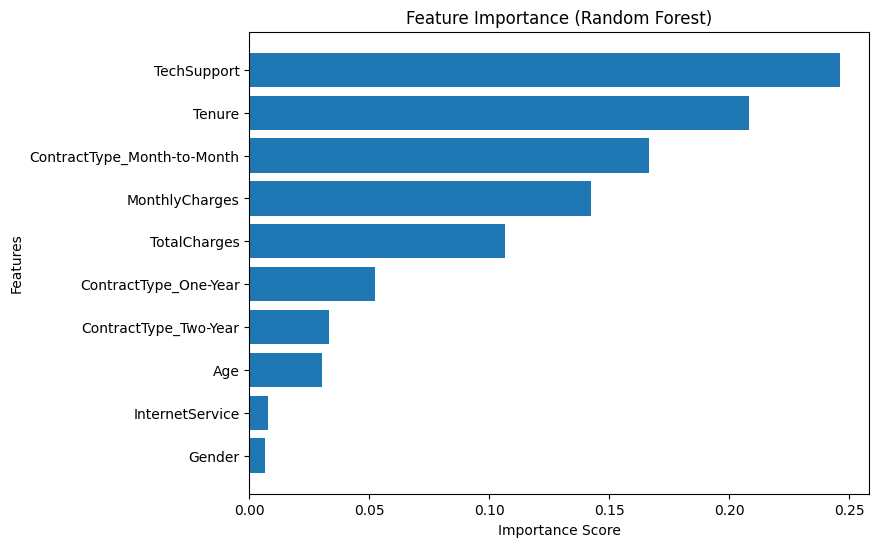

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model1.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({'Feature': features,'Importance': importances})
# Sort for better visualization
fi_df = fi_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(8,6))
plt.barh(fi_df['Feature'], fi_df['Importance'])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [80]:
import joblib

joblib.dump(model1, 'churn_model.pkl')


['churn_model.pkl']

XGBoost

In [74]:
#XGBoost
from xgboost import XGBClassifier

model2 = XGBClassifier()
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nDetailed Report:\n", classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0
F1 Score: 1.0

Detailed Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 23   0]
 [  0 177]]


this model(xgboost) also made no errors. It correctly predicted all cases with 23 true positives and 177 true negatives.

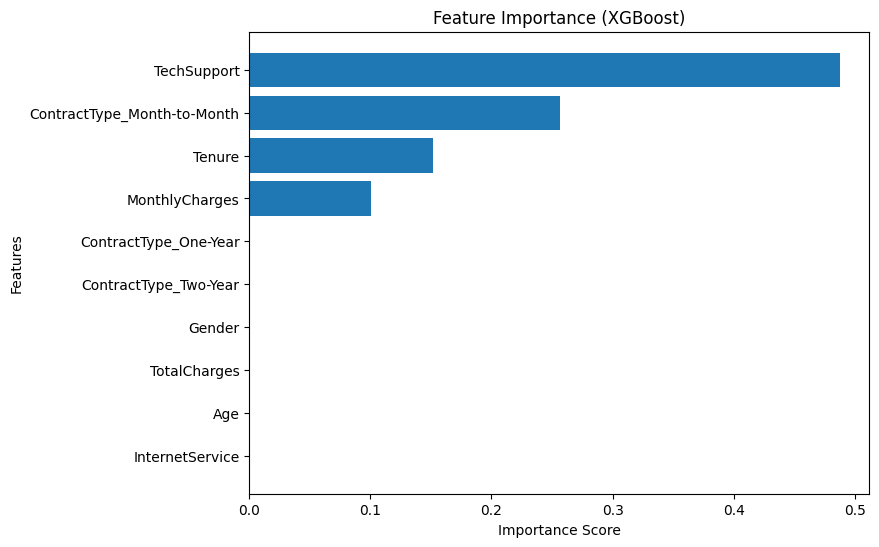

In [75]:
importances = model2.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({'Feature': features,'Importance': importances})

fi_df = fi_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(fi_df['Feature'], fi_df['Importance'])

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

We can see that TechSupport is the most important feature for both me models(RF,XGBOOST)


MODEL COMAPRISION (plotting)

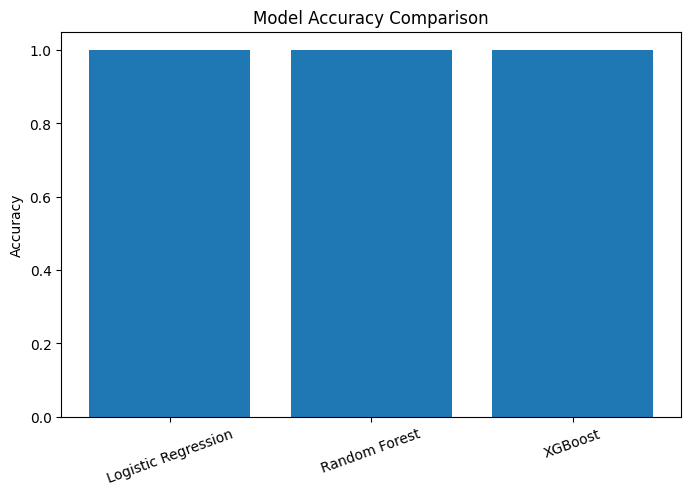

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = [model, model1, model2]
names = ['Logistic Regression', 'Random Forest', 'XGBoost']

accuracies = [
    accuracy_score(y_test, model.predict(X_test)),
    accuracy_score(y_test, model1.predict(X_test)),
    accuracy_score(y_test, model2.predict(X_test))
]

plt.figure(figsize=(8,5))
plt.bar(names, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()


From the above comaprison we can come to the conclusion that both the models Random forest and XGBoost performs a bit better than the logistic regression model.


In [81]:
from google.colab import files
files.download('churn_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>